# Stellar companion

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import GaiaAstrometry
from exogaia.leastsq import LeastSquares

In [3]:
source_id = 6199395656645840384  # HD 135344 A
primary_mass = (2.2, 0.1)  # (Msun)
mass_2 = 1.5  # (Msun)

In [4]:
epoch_astrom = GaiaAstrometry(primary_mass=primary_mass, gaia_release='DR4')


Gaia astrometry

Gaia release: DR4
Reference epoch: J2017.500

Primary mass (Msun): 2.20 +/- 0.10


In [5]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6199395656645840384

INFO: Query finished. [astroquery.utils.tap.core]

RA = 228.954 deg +/- 0.038 mas
Dec = -37.149 deg +/- 0.026 mas
Parallax = 7.411 +/- 0.040 mas
Proper motion in RA = -18.738 +/- 0.051 mas/yr
Proper motion in Dec = -24.008 +/- 0.035 mas/yr
G-band magnitude = 7.748
Pseudocolor = 1.73 um-1

UWE = 1.96
RUWE = 0.95
Astrometric excess noise (mas) = 0.2075 +/- 0.0103
Non single star = 0


In [6]:
model_param = {
    'ecc': 0.0,
    'tau': 0.5,
    'inc': np.radians(30.),
    'aop': np.radians(0.),
    'pan': np.radians(90.),
    'sma': 2.,
}

In [7]:
model_param = epoch_astrom.simulate_data(
    model_param=model_param,
    mass_2=mass_2,
    flux_ratio=None,
    occ_rate=None,
    sigma_per_ccd=None,
    csv_out=None,
    seed=1,
    reject_fraction=False,
)


-------------
Simulate data
-------------

System type: binary

Primary mass (Msun): 2.20 +/- 0.10

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Additional parameters:
   - Primary mass (Msun) = 2.20
   - Companion mass (Msun) = 1.50e+00
   - Mass ratio = 6.82e-01
   - Flux ratio = 2.62e-01
   - Relative semi-major axis (au) = 2.00

Star model

Epoch astrometry: GaiaAstrometry

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.000
   - Dec offset (mas) = 0.000
   - Parallax (mas) = 7.411
   - Proper motion in RA (mas/yr) = -18.738
   - Proper motion in Dec (mas/yr) = -24.008

Kepler model

Epoch astrometry: GaiaAstrometry

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 537.074
   - Eccentricity = 0.000
   - Relative time of periastron = 0.500
   - Semi-major axis (mas) = 14.821
   - Inclination (deg) = 30.000
   - A

In [8]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 2.871

Best-fit stellar track:
   - RA offset (mas) = -0.068 +/- 0.025
   - Dec offset (mas) = -0.021 +/- 0.017
   - Parallax (mas) = 7.318 +/- 0.029
   - mu in RA (mas/yr) = -18.741 +/- 0.016
   - mu in Dec (mas/yr) = -23.998 +/- 0.010

Best-fit orbit:
   - Period (days) = 528.966
   - Eccentricity = 0.000
   - Relative time of periastron = 0.93
   - Thiele-Innes A = 1.061 +/- 0.027
   - Thiele-Innes B = 2.718 +/- 0.035
   - Thiele-Innes F = -2.200 +/- 0.022
   - Thiele-Innes G = 1.199 +/- 0.035

Derived parameters:
   - Semi-major axis of photocenter (mas) = 2.974 +/- 0.034
   - Relative semi-major axis (au) = 1.812
   - Mass function (Msun) = 3.200e-02
   - Companion mass (Msun) = 6.361e-01

Conversion to Campbell elements:
   - Period = 528.966 days
   - Eccentricity = 0.000
   - Relative time of periastron = 0.933
   - Semi-major axis of photocenter (mas) = 2.974
   - Inclination (deg) = 34.942
   - Argument of periastron (deg) = 340.179
   - PA of ascending node 

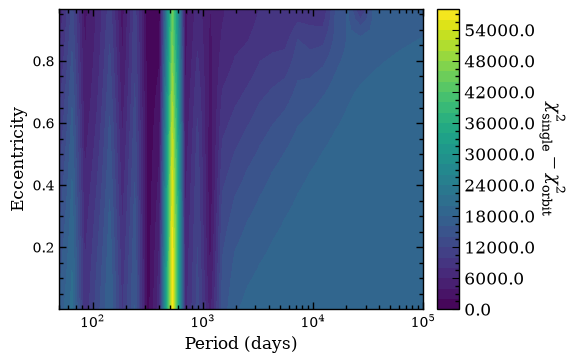

In [9]:
fig = leastsq.orbit_grid(n_points=30, map_type="chi2_det", plot_file='orbit_grid.png')


-------------------------
Orbit fit (12 parameters)
-------------------------

Reduced chi^2: 0.477
RUWE: 0.690

Best-fit stellar track:
   - RA offset (mas) = -0.013 +/- 0.046
   - Dec offset (mas) = -0.007 +/- 0.011
   - Parallax (mas) = 7.411 +/- 0.017
   - mu in RA (mas/yr) = -18.736 +/- 0.010
   - mu in Dec (mas/yr) = -24.006 +/- 0.006

Best-fit orbit:
   - Period (days) = 537.107 +/- 0.332
   - Eccentricity = 0.000 +/- 0.010
   - Relative time of periastron = 0.995 +/- 0.006
   - Semi-major axis of photocenter (mas) = 2.951 +/- 0.020
   - Inclination (deg) = 30.308 +/- 0.916
   - Argument of periastron (deg) = 359.697 +/- 0.051
   - PA of ascending node (deg) = 88.666 +/- 1.960

Number of function evaluations: 15
Number of Jacobian evaluations: 10

Derived parameters:
   - Relative semi-major axis (au) = 1.826
   - Mass function (Msun) = 2.920e-02
   - Companion mass (Msun) = 6.137e-01


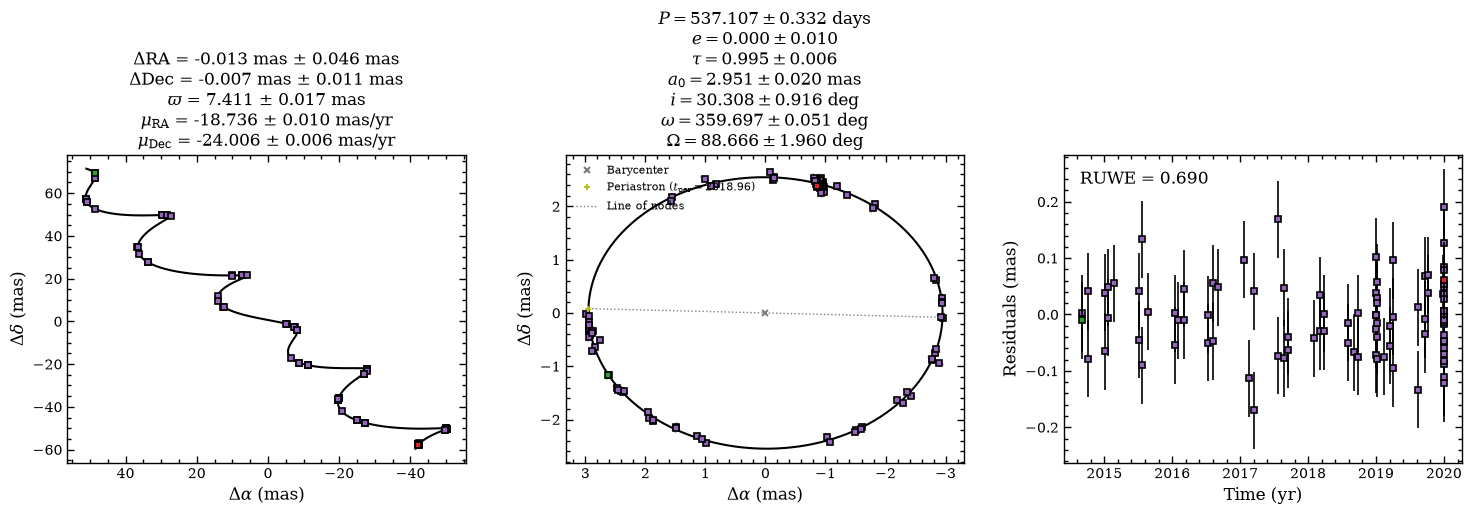

In [10]:
fig = leastsq.orbit_fit(inc_jitter=False, plot_file='orbit_fit.png')

Because the secondary star contributes non-negligible flux, the observed photocenter orbit differs from the orbit expected for a dark companion. The orbital period is therefore recovered correctly, but the inferred relative semimajor axis ($1.8$ au) and companion mass ($0.6$ $M_\odot$) are smaller than their true values ($2$ au and $1.5$ $\,M_\odot$, respectively).